<a href="https://colab.research.google.com/github/mdfaheem23/Space_SBI/blob/main/Copy_of_TauREx_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to TauREx 3

We will use this notebooks to introduce ourselves to the TauREx platform. For this introduction we will go through the basics of:

- Installing ``taurex``
- Acquiring some opacity data
- Creating a model
- Running the model


First, installing taurex is simply done like so:

In [1]:
!pip install -U taurex[numba]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.7/238.7 kB 27.5 MB/s eta 0:00:00


Checking its version it a good way to see if its installed:

In [2]:
import taurex
taurex.__version__

'3.3.2'

If you have any warnings don't worry, these are optional features that can be enabled by installing extra libraries.

Now before we move on we should get some opacity data.

# Opacities

Opacities describe optical behaviour of some physical property in the atmosphere. Some can be computed while others must be loaded in.
The main opacities used in TauREx are molecular absorption cross-sections.

These require computation from a molecular line-list such as those from the [ExoMol](https://www.exomol.com) project but thankfully these generous people have computed some already for use.

TauREx supports many formats


For our purposes we will be using 4 molecules:

- $H_2O$ from [POZAKATEL linelist](https://exomol.com/data/molecules/H2O/1H2-16O/POKAZATEL/)
- $CH_4$ from [MM linelist](https://exomol.com/data/molecules/CH4/12C-1H4/MM/)
- $NH_3$ from [CoYuTe linelist](https://exomol.com/data/molecules/NH3/14N-1H3/CoYuTe/)
- $CO_2$ from [UCL-4000 linelist](https://exomol.com/data/molecules/CO2/12C-16O2/UCL-4000/)

*Please make sure you site the linelists individually if you use them for your work*

In [3]:
!mkdir xsec/

!wget https://raw.githubusercontent.com/ucl-exoplanets/taurex-playground/refs/heads/main/scripts/bootstrap_exomol.py

!python bootstrap_exomol.py -m H2O -m CO2 -m CH4 -m NH3 -m HCN -m TiO -o ./xsec

--2026-08-26 05:31:42--  https://raw.githubusercontent.com/ucl-exoplanets/taurex-playground/refs/heads/main/scripts/bootstrap_exomol.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2528 (2.5K) [text/plain]
Saving to: ‘bootstrap_exomol.py’

bootstrap_exomol.py 100%[===================>]   2.47K  --.-KB/s    in 0s      

2026-08-26 05:31:42 (43.2 MB/s) - ‘bootstrap_exomol.py’ saved [2528/2528]


...100%, 348 MB, 17746 KB/s, 20 seconds passed
...100%, 348 MB, 17830 KB/s, 20 seconds passed
...100%, 348 MB, 16640 KB/s, 21 seconds passed
...100%, 348 MB, 17919 KB/s, 19 seconds passed
...100%, 348 MB, 7511 KB/s, 47 seconds passed
...100%, 348 MB, 18594 KB/s, 19 seconds passed

Additionally we will also like to include conditionally induced absorption. We will grab these from the [HITRAN](https://hitran.org/) database. Specifically $H_2-H_2$ and $H_2-He$ pairs.

In [4]:
!mkdir -p cia

!curl -L https://hitran.org/data/CIA/main/H2-H2_2011.cia -o ./cia/H2-H2_CIA.cia
!curl -L https://hitran.org/data/CIA/main/H2-He_2011.cia -o ./cia/H2-He_CIA.cia

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 23.6M  100 23.6M    0     0  4086k      0  0:00:05  0:00:05 --:--:-- 6085k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  140M  100  140M    0     0  1715k      0  0:01:23  0:01:23 --:--:-- 2520k


# Loading in our opacities

TauREx makes use of an automated opacity loader. By pointing to a directory, TauREx will attempt to discover, determine the filetype and identify the molecule. For molecular cross-sections, TauREx supports:

- Legacy TauREx 2 ``pickle`` format
- [ExomolOP](https://www.aanda.org/articles/aa/full_html/2021/02/aa38350-20/aa38350-20.html) HDF5 format.
- [ExoTransmit](https://github.com/elizakempton/Exo_Transmit) format

Additionally, some ``plugins`` can extend the formats that can be used.

For CIA we support:

- Legacy TauREx 2 ``.db`` format
- HITRAN ``.cia`` format

To load in our opacities we can make use of the ``OpacityCache`` and ``CIACache`` objects and point them to our folders.

In [5]:
from taurex.cache import OpacityCache, CIACache

OpacityCache().set_opacity_path('./xsec/')
CIACache().set_cia_path('./cia/')


🚀 **TIP**
``OpacityCache`` and ``CIACache`` are actually [Singletons](https://en.wikipedia.org/wiki/Singleton_pattern). This means that calling their constructor will always return the same object!

Now we can see what the ``OpacityCache`` has found:

In [6]:
OpacityCache().find_list_of_molecules()

{'CH4', 'CO2', 'H2O', 'HCN', 'NH3', 'TiO'}

Our molecules were found! Great! Now we can move on to building our model

# Building models

TauREx constructs a simulation by putting together pieces to form a complete model.

The baseline TauREx can build three types of models:

- [TransmissionModel](https://taurex3.readthedocs.io/en/latest/api/taurex.model.html#taurex.model.transmission.TransmissionModel) - Transit spectral modelling
- [EmissionModel](https://taurex3.readthedocs.io/en/latest/api/taurex.model.html#taurex.model.emission.EmissionModel) - Eclipse spectral modelling
- [DirectImageModel](https://taurex3.readthedocs.io/en/latest/api/taurex.model.html#taurex.model.directimage.DirectImageModel) - Direct Imaging model

In order to accomplish this, we need to build some of the pieces first:

1. Temperature Model
2. Pressure Model
3. Chemical Model
4. Optical depth Model.
5. Planet
6. Star


## Temperature model

Vanilla TauREx 3 has a few temperature models available:

- ``Isothermal``
- [Guillot2010](https://www.aanda.org/articles/aa/abs/2010/12/aa13396-09/aa13396-09.html)
- ``NPoint``
- ``TemperatureFile``

All of them exist under the ``taurex.temperature`` module. Lets load up an ``Isothermal`` model and see how we create a profile that is a constant $2000~K$ along the atmosphere.

In [ ]:
from taurex.temperature import Isothermal

iso_t = Isothermal(T=2000.0)

Easy! Other profiles can be created the same way. You can always ask for help if you want to understand how to build one of them:

In [ ]:
from taurex.temperature import Guillot2010

Guillot2010?

## Pressure Profiles

Currently TauREx supports 2 types of pressure profiles:

- ``SimplePressureProfile``
- ``FilePressure``

The ``SimplePressureProfile`` profile simply builds a pressure profile equally spaced in the log scale.

Units are in $Pa$

In [ ]:
from taurex.pressure import SimplePressureProfile

press = SimplePressureProfile(
    nlayers=100,
    atm_min_pressure=1e-5,
    atm_max_pressure=1e5
)


## Chemistry Model

Baseline TauREx only has two chemical models:

- ``TaurexChemistry``
- ``ChemistryFile``

In particular ``TaurexChemistry`` is a model that allows for the free determination of chemical profiles for our chosen molecules.

We define **fill gases** which will be used to fill up the remaining atmosphere after we include our molecules.

The ratio is used if we have more that one fill gas.

In [ ]:
from taurex.chemistry import TaurexChemistry

chemistry = TaurexChemistry(fill_gases=["H2", "He"], ratio=0.1756)

### Adding molecules

Now we can start adding molecules, ``TaurexChemistry`` has the ``addGas`` method which can be used to insert molecules into the chemical model. We can use the ``ConstantGas`` profile but there is the ``TwoLayerGas`` available as well.

TauREx uses *volume mixing ratio (VMR)*

In [ ]:
from taurex.chemistry import ConstantGas

gas = ConstantGas(molecule_name="H2O", mix_ratio=1e-3)
chemistry.addGas(gas)

We can also create it on the spot:

In [ ]:
chemistry.addGas(ConstantGas(molecule_name="CH4", mix_ratio=1e-4))

And also chain ``addGas`` calls:

In [ ]:
chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=1e-4)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=1e-4))
#

Now chemistry has an interesting property. There is an ``activeGases`` and ``inactiveGases``

*Active Gases:*
- Have molecular cross-sections loaded in

*Inactive Gases:*
- Do not have molecular cross-sections

Now inactive does not mean they are completely spectrscopically inactive (as they may come in the form of CIA or rayleigh).

We can check them with these properties:

In [ ]:
chemistry.inactiveGases, chemistry.activeGases

(('H2', 'He'), ('H2O', 'CH4', 'NH3', 'CO2'))

Our chemistry is setup!

## Star and Planet

TauRex requires information about the planet and star in the system in order to simulate the spectra.
The planet contains properties such as:
- Mass ($M_{jup}$)
- Radius ($R_{jup}$)
- Semi-Major Axis ($AU$)
- Impact parameter
- Orbital Period ($day$)
- Albedo
- Transit time ($s$)

Not all of these are required for a particular spectrum. For example, transits only require ``mass`` and ``radius`` to be defined.

Lets create our favourite planet HD 209458 b

In [ ]:
from taurex.planet import Planet

planet = Planet(planet_mass=0.74, planet_radius=1.38)


For the star we can choose between:

- ``BlackbodyStar``
- ``PhoenixStar``

For this purpose we will stick with the ``BlackbodyStar`` as we do not possess the pre-requisite PHOENIX spectrum yet.

With the star we can define these properties:

- Effective Temperaure ($K$)
- Radius ($R_{sun}$)
- Distance ($pc$)
- Mass ($M_{sun}$)
- metallicity ($Z_{sun}$)

Again for our purposes, only ``temperature`` and ``radius`` are needed for transits and eclipse. Direct image requires the ``distance`` parameter.

In [ ]:
from taurex.stellar import BlackbodyStar

star = BlackbodyStar(temperature=6117, radius=1.16)

## Putting it together!

Now we have all of the pieces, we can put them together into a single model.

Lets build a transit model and try it out!

In [ ]:
from taurex.model import TransmissionModel
tm = TransmissionModel(planet=planet,
                       temperature_profile=iso_t,
                       chemistry=chemistry,
                       star=star,
                        pressure_profile=press)

At this point our atmosphere has profiles but no physics! We can add this by including some contributions. Lets add in Absorption:

In [ ]:
from taurex.contributions import AbsorptionContribution
tm.add_contribution(AbsorptionContribution())

Great! No all we have to do is build it:

In [ ]:
tm.build()

``build`` only needs to be done once if none of the models have changed. If you have replaced them then ``build`` needs to be run again.

Now we can actually run our model! The inital run may take a while as data is loaded in:

In [ ]:
wngrid, rprs, tau, _ = tm.model()

Running it again is much faster!

In [ ]:
wngrid, rprs, tau, _ = tm.model()

The output spectral grid is in *wavenumbers* ($cm^{-1}$). We can convert it into wavelength like so:

In [ ]:
wlgrid = 10000/wngrid[::-1]
rprs = rprs[::-1]

Lets plot the results!

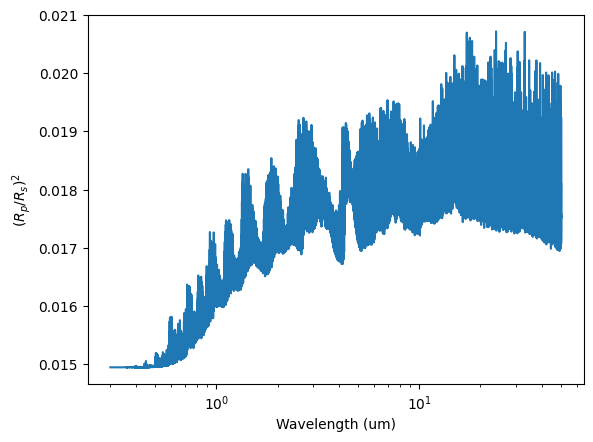

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(wlgrid, rprs)
plt.xlabel("Wavelength (um)")
plt.ylabel("$(R_p/R_s)^2$")
plt.xscale("log")

Of course we would like to add some other radiative effects. Lets put in CIA and see what happens:

In [ ]:
from taurex.contributions import CIAContribution
tm.add_contribution(CIAContribution(cia_pairs=['H2-H2','H2-He']))

tm.build()

In [ ]:
wngrid, rprs, tau, _ = tm.model()

wlgrid = 10000/wngrid[::-1]
rprs = rprs[::-1]

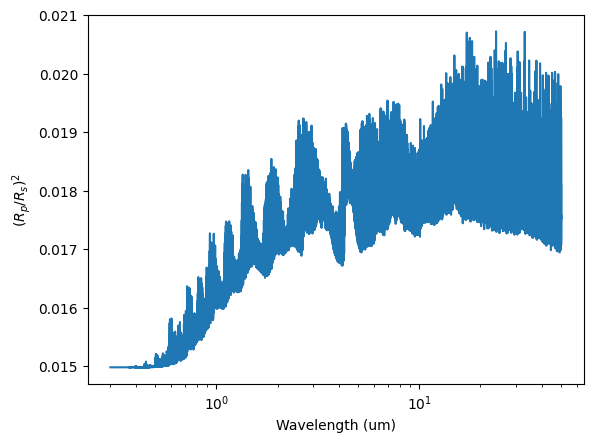

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(wlgrid, rprs)
plt.xlabel("Wavelength (um)")
plt.ylabel("$(R_p/R_s)^2$")
plt.xscale("log")

Its subtle but there is a difference, we can see something more dramatic with Rayleigh:

In [ ]:
from taurex.contributions import RayleighContribution
tm.add_contribution(RayleighContribution())

tm.build()

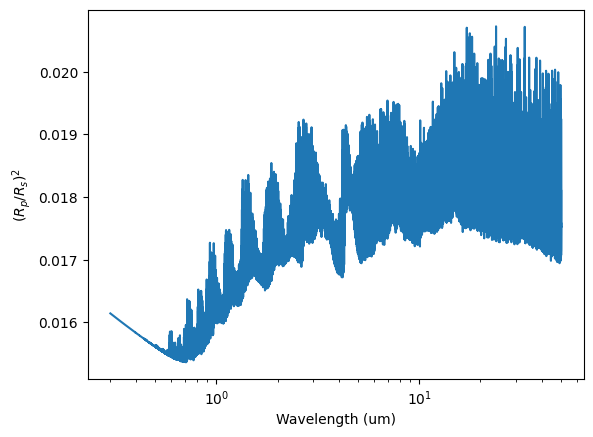

In [ ]:
wngrid, rprs, tau, _ = tm.model()

wlgrid = 10000/wngrid[::-1]
rprs = rprs[::-1]

plt.figure()
plt.plot(wlgrid, rprs)
plt.xlabel("Wavelength (um)")
plt.ylabel("$(R_p/R_s)^2$")
plt.xscale("log")

Ahh yes the distinctive slope!

Lets try using the same objects with Emission:

In [ ]:
from taurex.model import EmissionModel

em = EmissionModel(
    planet=planet,
    temperature_profile=iso_t,
    chemistry=chemistry,
    star=star,
    pressure_profile=press,
)

em.add_contribution(AbsorptionContribution())
em.add_contribution(CIAContribution(cia_pairs=['H2-H2','H2-He']))
em.add_contribution(RayleighContribution())

em.build()

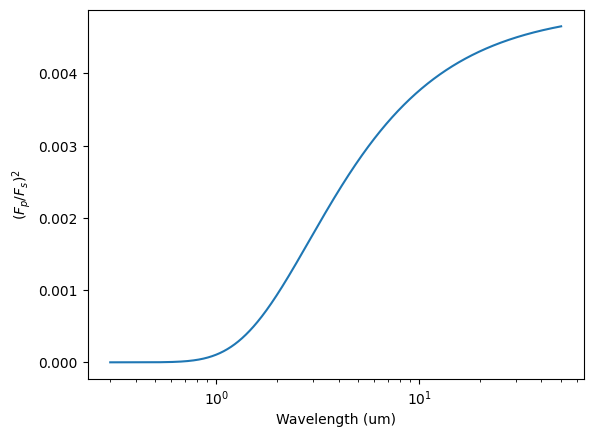

In [ ]:
wngrid, fpfs, tau, _ = em.model()

wlgrid = 10000/wngrid[::-1]
fpfs = fpfs[::-1]

plt.figure()
plt.plot(wlgrid, fpfs)
plt.xlabel("Wavelength (um)")
plt.ylabel("$(F_p/F_s)^2$")
plt.xscale("log")

Ahhh of course, an isothermal will lead to a blackbody spectrum! Okay lets replace the temperature profile with something less constant:

In [ ]:
from taurex.model import EmissionModel
from taurex.temperature import Guillot2010

em = EmissionModel(
    planet=planet,
    temperature_profile=Guillot2010(T_irr=1500),
    chemistry=chemistry,
    star=star,
    pressure_profile=press,
)

em.add_contribution(AbsorptionContribution())
em.add_contribution(CIAContribution(cia_pairs=['H2-H2','H2-He']))
em.add_contribution(RayleighContribution())

em.build()

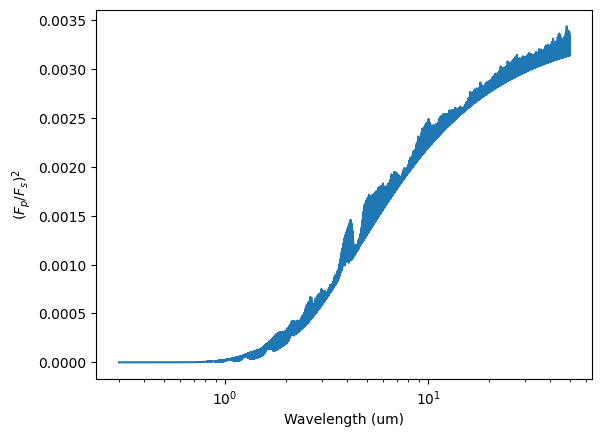

In [ ]:
wngrid, fpfs, tau, _ = em.model()

wlgrid = 10000/wngrid[::-1]
fpfs = fpfs[::-1]

plt.figure()
plt.plot(wlgrid, fpfs)
plt.xlabel("Wavelength (um)")
plt.ylabel("$(F_p/F_s)^2$")
plt.xscale("log")

# Clouds

TauREx also contains some scattering contributions that simulate the effect of clouds on a spectrum. Some of the *vanilla* cloud models in TauREx include:

- ``FlatMie``
   - A flat absorption across the spectrum with a defined cloud deck
- ``SimpleClouds``
   - An infinitely absorbing cloud deck up to a certain height
- ``LeeMie``
   - A Mie approximation according to [Lee at al 2013](https://iopscience.iop.org/article/10.1088/0004-637X/778/2/97)


We can play around with these clouds and see how they behave. Lets take our current transit model and add some clouds.

## Infinite cloud deck

Lets first try adding in an infinite cloud deck. We can define the top of the cloud deck via ``clouds_pressure``

In [ ]:
from taurex.contributions import SimpleCloudsContribution

clouds = SimpleCloudsContribution(clouds_pressure=1e3)
tm.add_contribution(clouds)
tm.build()

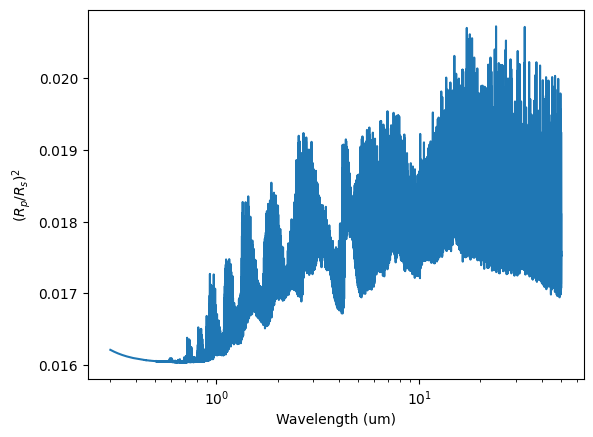

In [ ]:



wngrid, rprs, tau, _ = tm.model()

wlgrid = 10000/wngrid[::-1]
rprs = rprs[::-1]

plt.figure()
plt.plot(wlgrid, rprs)
plt.xlabel("Wavelength (um)")
plt.ylabel("$(R_p/R_s)^2$")
plt.xscale("log")

Interestingly this has the effect of *flattening the spectrum* we can play around with the cloud deck height by modifying the ``cloudsPressure`` variable

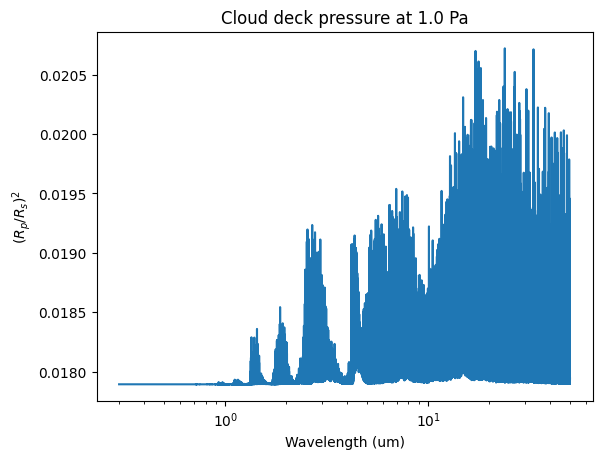

In [ ]:
clouds.cloudsPressure = 1e0

wngrid, rprs, tau, _ = tm.model()

wlgrid = 10000/wngrid[::-1]
rprs = rprs[::-1]

plt.figure()
plt.title(f"Cloud deck pressure at {clouds.cloudsPressure} Pa")
plt.plot(wlgrid, rprs)
plt.xlabel("Wavelength (um)")
plt.ylabel("$(R_p/R_s)^2$")
plt.xscale("log")

The infinitely absorbing cloud deck essentially flattens and mutes the spectrum. It has a similar effect of raising the percieved radius of the planet. This make sense as the *true radius* of the planet from a lightcurve would be indistingushable from a thick cloud that absorbs at all wavelengths.

## Flat Cloud

Flat clouds work similarly to the infinite deck but allow us control of how much absorption and where the cloud deck starts as well. The absorption is equal on all wavelengths so we can consider it as *grey*.

Our parameters are:
- ``mix_ratio`` which defines how much absoprtion.
- ``flat_bottomP`` which controls where the cloud deck starts (from BOA)
- ``flat_topP`` which controls where the cloud deck ends. (from BOA)

Setting ``bottomP=-1`` and ``mix_ratio=np.inf`` will be equivalent to the infinite cloud deck.

Before we move on lets define a function to *decloud* the atmosphere, this make it easy for us to replace clouds without recreating the model.




In [ ]:
def decloud(tm):
  tm.contribution_list = [c for c in tm.contribution_list if isinstance(
      c,
      (AbsorptionContribution, CIAContribution, RayleighContribution))]

In [ ]:
decloud(tm)

Now lets add in the flat cloud. We can start it at the bottom of the atmosphere and stop at around $10^3~Pa$

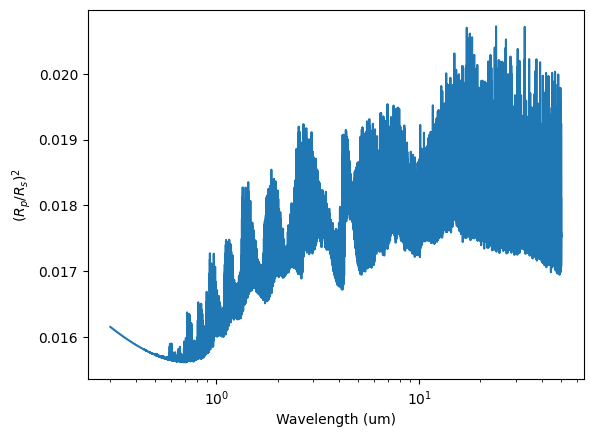

In [ ]:
from taurex.contributions import FlatMieContribution

decloud(tm)

clouds = FlatMieContribution(
    flat_mix_ratio=1e-31,
    flat_bottomP=-1,
    flat_topP=1e3
)

tm.add_contribution(clouds)
tm.build()

wngrid, rprs, tau, _ = tm.model()

wlgrid = 10000/wngrid[::-1]
rprs = rprs[::-1]

plt.figure()
plt.plot(wlgrid, rprs)
plt.xlabel("Wavelength (um)")
plt.ylabel("$(R_p/R_s)^2$")
plt.xscale("log")

The behaviour is a little more interesting as its muting the rayleigh contribution a lot more but not as much as the infinite model.

We can zero the opacity to simulate cloudless atmosphere and increase it significantly to simulate thick clouds (Like the infinite one)

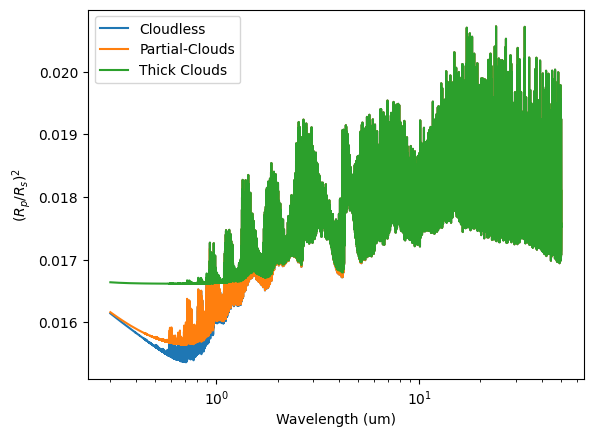

In [ ]:
clouds.mieTopPressure = 1e2
clouds.mieBottomPressure = -1

# No clouds
clouds.mieMixing = 0

wngrid, rprs, tau, _ = tm.model()

wlgrid = 10000/wngrid[::-1]
cloudless_rprs = rprs[::-1]

# Thick clouds
clouds.mieMixing = 1e10

wngrid, rprs, tau, _ = tm.model()

wlgrid = 10000/wngrid[::-1]
thick_rprs = rprs[::-1]

# 'Mid' clouds
clouds.mieMixing = 1e-31

wngrid, rprs, tau, _ = tm.model()

wlgrid = 10000/wngrid[::-1]
partial_rprs = rprs[::-1]


plt.figure()
plt.plot(wlgrid, cloudless_rprs, label="Cloudless")
plt.plot(wlgrid, partial_rprs, label="Partial-Clouds")
plt.plot(wlgrid, thick_rprs, label="Thick Clouds")
plt.xlabel("Wavelength (um)")
plt.ylabel("$(R_p/R_s)^2$")
plt.legend()
plt.xscale("log")

Play around with the top/bottom and mixing values and see how the clouds change the behaviour of the spectrum!

## LeeMie

``LeeMie`` clouds are a Mie scattering approximation that accounts for particle radius, extinction and density. They require a little more care in accurately modelling but a more "physically motivated" approximation to cloud behaviour.

As before lets decloud our model:

In [ ]:
decloud(tm)

First lets store a cloudless version of the atmosphere for comparison.

In [ ]:
# lets take a cloudless model first
tm.build()
wngrid, rprs, tau, _ = tm.model()

wlgrid = 10000/wngrid[::-1]
cloudless_rprs = rprs[::-1]


Now lets add LeeMie to the model:

In [ ]:
from taurex.contributions import LeeMieContribution
decloud(tm)
clouds = LeeMieContribution(
)

tm.add_contribution(clouds)
tm.build()

Now we model and plot:

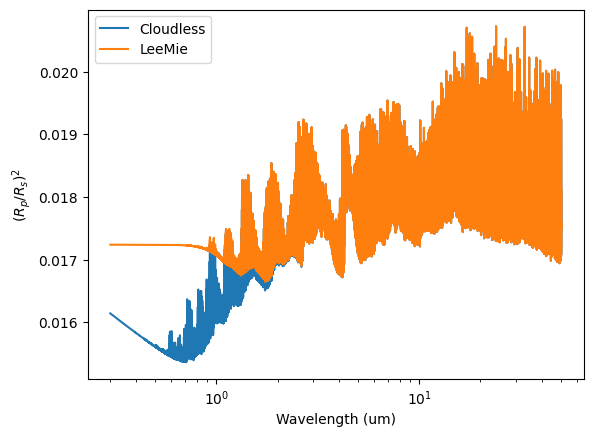

In [ ]:
# Particle radius
clouds.mieRadius = 0.01
# Mie extinction
clouds.mieQ = 40
# Particle mixing in particles/m3
clouds.mieMixing = 1e14
# Top Deck pressure
clouds.mieTopPressure = 1e1
# bottom deck pressure
clouds.mieBottomPressure = -1


wngrid, rprs, tau, _ = tm.model()

wlgrid = 10000/wngrid[::-1]
lee_rprs = rprs[::-1]

plt.figure()
plt.plot(wlgrid, cloudless_rprs, label="Cloudless")
plt.plot(wlgrid, lee_rprs, label="LeeMie")
plt.xlabel("Wavelength (um)")
plt.ylabel("$(R_p/R_s)^2$")
plt.legend()
plt.xscale("log")
plt.savefig("simulation.svg")


This model provides a wavelength dependant cloud model, as you can see there is a flattening in the optical wavelengths but this reduces as we move to the IR. This makes sense as there is a dependancy with particle radius and scattering. Try modifying the particle radius to ``0.1`` and see what happens

Lee Mie is a decent approximation simulate clouds that are not *grey*.


# Inspecting the model

We can inspect various aspects of the model we've build by accesing its properties. For example, lets see the temperature profile:

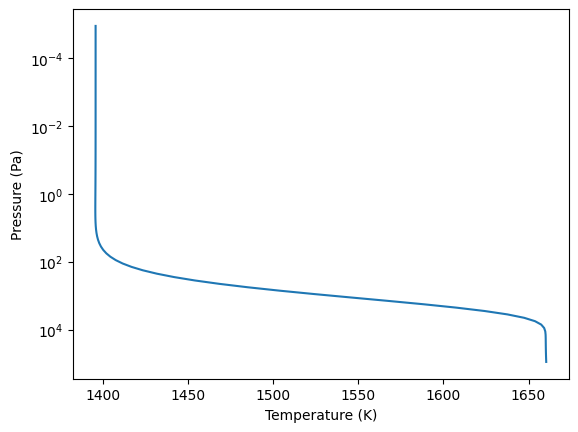

In [ ]:
plt.figure()
plt.plot(em.temperatureProfile, em.pressureProfile)
plt.xlabel("Temperature (K)")
plt.ylabel("Pressure (Pa)")
# Flip the Y axis
plt.gca().invert_yaxis()
plt.yscale("log")


Or even the chemical profile

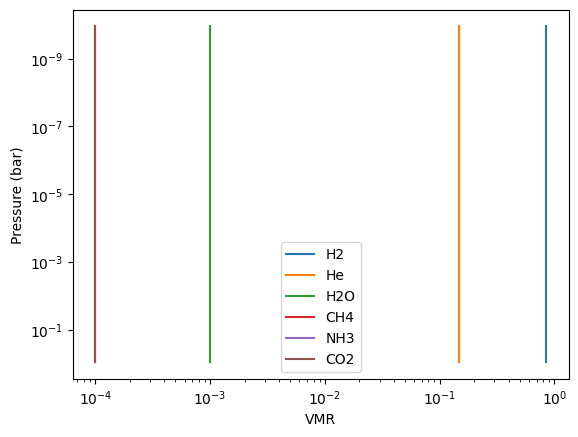

In [ ]:
plt.figure()

for x,gasname in enumerate(em.chemistry.gases):

    plt.plot(em.chemistry.mixProfile[x],em.pressureProfile/1e5,label=gasname)

plt.gca().invert_yaxis()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("VMR")
plt.ylabel("Pressure (bar)")
plt.legend()
plt.show()

Or properties like the density, altitude, mean molecular weight

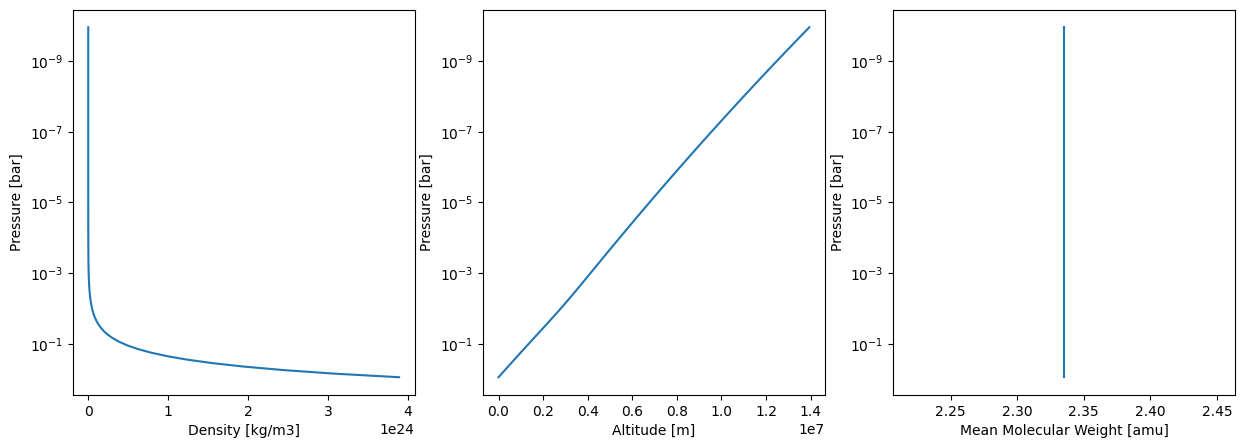

In [ ]:
from taurex.constants import AMU
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,5))

ax1.plot(em.densityProfile,em.pressureProfile/1e5)
ax1.invert_yaxis()
ax1.set_xlabel('Density [kg/m3]')
ax1.set_ylabel('Pressure [bar]')
ax1.set_yscale("log")

ax2.plot(em.altitudeProfile,em.pressureProfile/1e5)
ax2.invert_yaxis()
ax2.set_xlabel('Altitude [m]')
ax2.set_ylabel('Pressure [bar]')
ax2.set_yscale("log")
ax3.plot(em.chemistry.mu_profile/AMU,em.pressureProfile/1e5)
ax3.invert_yaxis()
ax3.set_xlabel('Mean Molecular Weight [amu]')
ax3.set_ylabel('Pressure [bar]')
ax3.set_yscale("log")

# Input file

Input files that are loaded into the ``taurex`` program can also be used to load in models.

For example, the transmission model we have defined has an equivalent cloudless version as an input file

🚀**TIP** We are generating an input file on the spot by doing this.

In [ ]:
%%sh
cat > input.par << EOF
[Global]
xsec_path = ./xsec
cia_path = ./cia


[Chemistry]
chemistry_type = taurex
fill_gases = H2,He
ratio = 0.1741

    [[H2O]]
    gas_type=constant
    mix_ratio = 1e-3

    [[CH4]]
    gas_type=constant
    mix_ratio = 1e-4

    [[NH3]]
    gas_type=constant
    mix_ratio = 1e-4

    [[CO2]]
    gas_type=constant
    mix_ratio = 1e-4

[Temperature]
profile_type = isothermal
T = 2000

[Pressure]
profile_type = Simple
atm_min_pressure = 1e-5
atm_max_pressure = 1e5
nlayers = 100

[Planet]
planet_type = Simple
planet_mass = 0.74
planet_radius = 1.38

[Star]
star_type = blackbody
temperature = 6117
radius = 1.16

[Model]
model_type = transmission

    [[Absorption]]
    [[CIA]]
    cia_pairs = H2-H2,H2-He
    [[Rayleigh]]

EOF
ls -l

total 436
-rw-r--r-- 1 root root   2528 Jul 30 15:39 bootstrap_exomol.py
-rw-r--r-- 1 root root   2528 Jul 30 15:49 bootstrap_exomol.py.1
-rw-r--r-- 1 root root   2528 Jul 30 16:13 bootstrap_exomol.py.2
-rw-r--r-- 1 root root   2528 Jul 30 16:33 bootstrap_exomol.py.3
drwxr-xr-x 2 root root   4096 Jul 30 16:13 cia
-rw-r--r-- 1 root root    733 Jul 30 16:37 input.par
drwxr-xr-x 1 root root   4096 Jun  4 13:39 sample_data
-rw-r--r-- 1 root root 411567 Jul 30 16:37 simulation.svg
drwxr-xr-x 2 root root   4096 Jul 30 15:41 xsec


In [ ]:
! taurex -i input.par -o output.hdf5

taurex - INFO - TauREx 3.3.2
taurex - INFO - TauREx PROGRAM START AT 2026-07-30 16:37:26.516802
taurex.ParamParser - INFO - Interpolation mode set to linear
taurex.ParamParser - WARNING - Xsecs will be loaded in memory
taurex.ParamParser - WARNING - Radis is disabled
taurex.ParamParser - WARNING - Radis default grid will be used
taurex.ClassFactory - INFO - Reloading all modules and plugins
taurex.ClassFactory - INFO - ----------Plugin loading---------
taurex.TransmissionModel - INFO - Building model........
taurex.TransmissionModel - INFO - Collecting paramters
taurex.TransmissionModel - INFO - Setting up profiles
taurex.TransmissionModel - INFO - Setting up contributions
taurex.TransmissionModel - INFO - DONE
taurex.OpacityCache - INFO - Reading opacity H2O
taurex.OpacityCache - INFO - Loading opacity H2O into model
taurex.OpacityCache - INFO - Reading opacity CH4
taurex.OpacityCache - INFO - Loading opacity CH4 into model
taurex.OpacityCache - INFO - Reading opacity NH3
taurex.Opaci

In [ ]:
!taurex-plot --help

usage: taurex-plot [-h] -i INPUT_FILE [-P] [-x] [-D] [-t] [-d] [-s] [-c] [-C]
                   [-a] [-T TITLE] -o OUTPUT_DIR [-p PREFIX] [-m CMAP]
                   [-R RESOLUTION]

Taurex-Plotter

options:
  -h, --help            show this help message and exit
  -i INPUT_FILE, --input INPUT_FILE
                        Input hdf5 file from taurex
  -P, --plot-posteriors
                        Plot fitting posteriors
  -x, --plot-xprofile   Plot molecular profiles
  -D, --plot-cprofile   Plot condensate profiles
  -t, --plot-tpprofile  Plot Temperature profiles
  -d, --plot-tau        Plot optical depth contribution
  -s, --plot-spectrum   Plot spectrum
  -c, --plot-contrib    Plot contrib
  -C, --full-contrib    Plot detailed contribs
  -a, --all             Plot everythiong
  -T TITLE, --title TITLE
                        Title of plots
  -o OUTPUT_DIR, --output-dir OUTPUT_DIR
                        output directory to store plots
  -p PREFIX, --prefix PREFIX
                 

In [ ]:
!convert output_spectrum_contrib_forward.pdf output_spectrum_contrib_forward.png

/bin/bash: line 1: convert: command not found


We can load in this par file like so:

In [ ]:
from taurex.parameter import ParameterParser

pp = ParameterParser()

pp.read("input.par")
pp.setup_globals()

tm = pp.generate_appropriate_model()

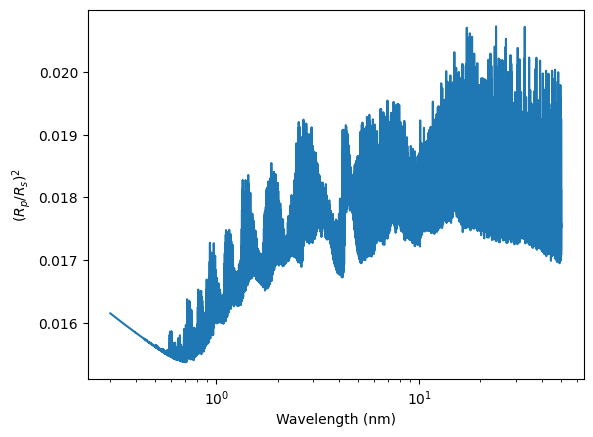

In [ ]:
tm.build()

wngrid, rprs, tau, _ = tm.model()

wlgrid = 10000/wngrid[::-1]
rprs = rprs[::-1]

plt.figure()
plt.plot(wlgrid, rprs)
plt.xscale('log')
plt.xlabel('Wavelength (nm)')
plt.ylabel('$(R_p/R_s)^2$')
plt.show()

🚀 **TIP**: You can find out how define a parfile from the [taurex3 documentation](https://taurex3.readthedocs.io/en/latest/user/taurex/index.html)

# Updating the model

It is possible to update a models parameters after it has been built. Each model can use the square bracket notation ``[]`` to access parameters and modify them after the fact. This is one of TauREx-3's key features.

For example we can pump up the temperature to 6000 K:

In [ ]:
tm["T"] = 2000.0

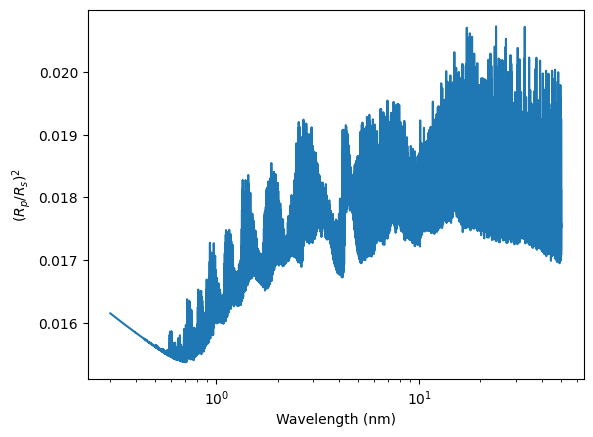

In [ ]:
wngrid, rprs, tau, _ = tm.model()

wlgrid = 10000/wngrid[::-1]
rprs = rprs[::-1]

plt.figure()
plt.plot(wlgrid, rprs)
plt.xscale('log')
plt.xlabel('Wavelength (nm)')
plt.ylabel('$(R_p/R_s)^2$')
plt.show()

And remove water entirely:

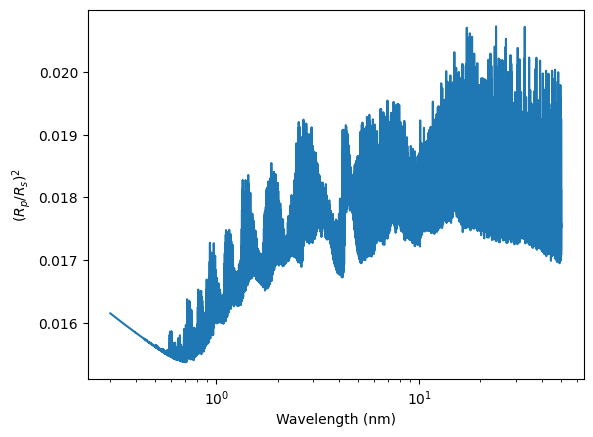

In [ ]:
tm["H2O"] = 1e-3


wngrid, rprs, tau, _ = tm.model()

wlgrid = 10000/wngrid[::-1]
rprs = rprs[::-1]

plt.figure()
plt.plot(wlgrid, rprs)
plt.xscale('log')
plt.xlabel('Wavelength (nm)')
plt.ylabel('$(R_p/R_s)^2$')
plt.show()

These brackets can also be used to see what the current variable is:

In [ ]:
print(f"Temperature is at {tm['T']}")
print(f"VMR of CO2 is {tm['CO2']}")


Temperature is at 2000.0
VMR of CO2 is 0.0001


To see the full parameters available to modify we can use the ``fittingParameters`` attribute.

In [ ]:
list(tm.fittingParameters.keys())

['planet_mass',
 'planet_radius',
 'planet_distance',
 'planet_sma',
 'distance',
 'atm_min_pressure',
 'atm_max_pressure',
 'T',
 'H2O',
 'CH4',
 'NH3',
 'CO2',
 'He_H2']

When we learn about retrievals we will understand why this feature of TauREx 3 is so important.

# Contributions to Spectra

We will also go through the process of seeing how each part of atmosphere and its processes contribute tot he final spectrum and flux of the planet.



## Depth contribution

We want to assess how each layer in the atmosphere contributes to the spectrum. This information is provided by the optical depth ($\tau$) from the modelling.

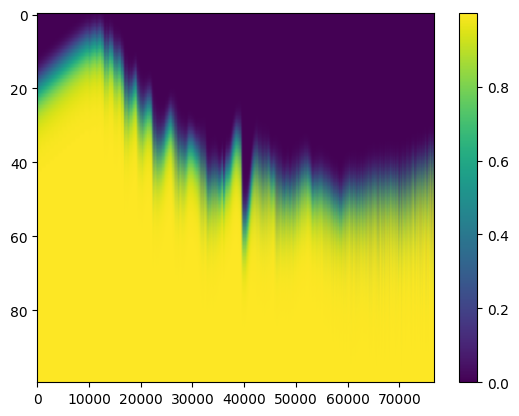

In [ ]:
wngrid, rprs, tau, _ = tm.model()

wlgrid = 10000/wngrid[::-1] # cm-1 to um
rprs = rprs[::-1]
tau = tau[...,::-1]

plt.figure()
plt.imshow(tau,aspect="auto")
plt.colorbar()
plt.show()


We dont have too much information about this without proper context so lets build a nicer way of plotting this:

In [ ]:
import numpy as np

def plot_optical_depth(ax, tau, pressure, wavelengths,
                       wl_ticks=6,
                       pressure_unit="Pa"):
  import numpy as np
  from matplotlib import ticker
  # Plot the optical depth
  im = ax.pcolormesh(wavelengths, pressure,tau)
  ax.set_xlabel("Wavelength (um)")
  ax.set_ylabel(f"Pressure ({pressure_unit})")
  ax.set_yscale("log")
  ax.set_xscale("log")
  start_wl = np.log10(wavelengths.min())
  end_wl = np.log10(wavelengths.max())

  ticks_wl = np.logspace(start_wl, end_wl, wl_ticks)

  ax.xaxis.set_major_locator(ticker.FixedLocator(ticks_wl))
  ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
  ax.invert_yaxis()
  # Add minor ticks for y axis
  locmin = ticker.LogLocator(base=10.0,subs=(0.2,0.4,0.6,0.8),numticks=12)
  ax.yaxis.set_minor_locator(locmin)
  ax.yaxis.set_minor_formatter(ticker.NullFormatter())



  return im



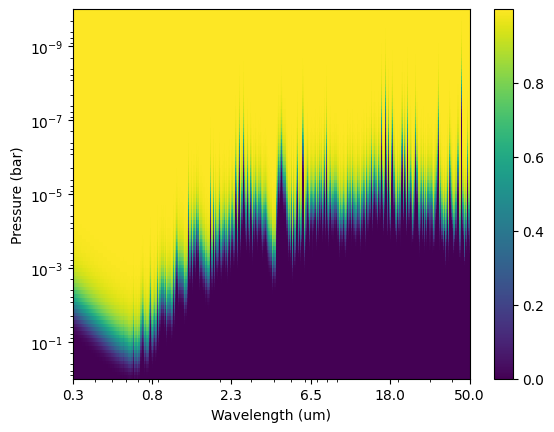

In [ ]:
fig, ax = plt.subplots()
im = plot_optical_depth(ax, tau, tm.pressureProfile/1e5, wlgrid,pressure_unit="bar")
fig.colorbar(im)
plt.show()

A much nicer plot! However it would also be good to see the average contribution at depth. We can compute this by taking the average along wavelength:

In [ ]:
def depth_contribution(tau):
    return np.average(tau, axis=1)

In [ ]:
depth_contribution(tau)

array([4.87323928e-04, 1.33130118e-03, 3.00581141e-03, 5.84897505e-03,
       1.01254177e-02, 1.59966955e-02, 2.34880454e-02, 3.25045073e-02,
       4.28834567e-02, 5.44043142e-02, 6.68235790e-02, 7.99133736e-02,
       9.34706664e-02, 1.07304015e-01, 1.21225838e-01, 1.35044690e-01,
       1.48574501e-01, 1.61648622e-01, 1.74180236e-01, 1.86115933e-01,
       1.97441278e-01, 2.08167033e-01, 2.18326630e-01, 2.27985299e-01,
       2.37231640e-01, 2.46177987e-01, 2.54952135e-01, 2.63699437e-01,
       2.72600850e-01, 2.81847614e-01, 2.91626275e-01, 3.02103851e-01,
       3.13480755e-01, 3.25991515e-01, 3.39450725e-01, 3.54396308e-01,
       3.71191785e-01, 3.89420051e-01, 4.09766998e-01, 4.32839259e-01,
       4.58173167e-01, 4.85287218e-01, 5.14618490e-01, 5.45576576e-01,
       5.77432967e-01, 6.10058140e-01, 6.42638766e-01, 6.74287160e-01,
       7.04950878e-01, 7.34351045e-01, 7.62192464e-01, 7.88263085e-01,
       8.12427114e-01, 8.34614575e-01, 8.54813695e-01, 8.73059829e-01,
      

Lets put them together and see what the depth-contribution looks like.

In [ ]:
# Lets create a grid specification
grid = plt.GridSpec(1, 4, wspace=0.4, hspace=0.3)
fig = plt.figure()
ax1 = fig.add_subplot(grid[0, :3])
ax2 = fig.add_subplot(grid[0, 3], sharey=ax1)

im = plot_optical_depth(ax1, tau, tm.pressureProfile/1e5, wlgrid, pressure_unit="bar")
ax2.plot(depth_contribution(tau), tm.pressureProfile/1e5)
ax2.yaxis.tick_right()
ax2.set_xlabel("Contribution")
plt.show()


Now we have a really good idea on how each layer influences the spectrum!

## Radiative Transfer contributions

We have a good idea of how deep we can see into the atmosphere, let us also examine how each part of the ``Contributions`` influences the shape of the spectrum!

When we model a spectrum, we can ask TauREx to model each contribution in isolation! This can be achieved with the ``model_full_contrib`` function. Lets try it out!

In [ ]:
wngrid, contribs = tm.model_full_contrib()
contribs

This is a fairly large dataset. Lets examine it carefully:

In [ ]:
contribs.keys()

We have each of the "contributions" to the spectrum listed. Lets examine the first one:

In [ ]:
len(contribs["Absorption"])

These are each of the molecules in the spectrum! Lets see one of them!

In [ ]:
absorption = contribs["Absorption"]
absorption[0]

The first is the ``label``, the second it the resultant spectrum (in this case $(R_p/R_s)^2$) if it was the only contributor. Lastly is the optical depth. We can plot these individually!

In [ ]:
label, abs_rprs, abs_tau, _ = absorption[0]

plt.figure()
plt.plot(wlgrid, rprs, label="Full spectrum")
plt.plot(wlgrid, abs_rprs[::-1], label=label)
plt.xlabel("Wavelength (um)")
plt.ylabel("$(R_p/R_s)^2$")
plt.xscale("log")
plt.legend()
plt.show()

Of course we removed water from last time. Lets update the model and try again!

In [ ]:
# Update our model parameters
tm["T"] = 1000.0
tm["H2O"] = 1e-4

# Remodel the full spectrum
wngrid, rprs, tau, _ = tm.model()

wlgrid = 10000/wngrid[::-1]
rprs = rprs[::-1]

# Model the contributions
wngrid, contribs = tm.model_full_contrib()

absorption = contribs["Absorption"]

# Extract water
label, abs_rprs, abs_tau, _ = absorption[0]

# Plot
plt.figure()
plt.plot(wlgrid, rprs, label="Full spectrum")
plt.plot(wlgrid, abs_rprs[::-1], label=label, alpha=0.6)
plt.xlabel("Wavelength (um)")
plt.ylabel("$(R_p/R_s)^2$")
plt.xscale("log")
plt.legend()
plt.show()

Very nice! Lets examing a different one, ``Rayleigh``

In [ ]:
rayleigh = contribs["Rayleigh"]
label, ray_rprs, ray_tau, _ = rayleigh[4]

plt.figure()
plt.plot(wlgrid, rprs, label="Full spectrum")
plt.plot(wlgrid, ray_rprs[::-1], label=label, alpha=0.6)
plt.xlabel("Wavelength (um)")
plt.ylabel("$(R_p/R_s)^2$")
plt.xscale("log")
plt.legend()

Nice! So we can see that the slope came from $H_2$ rayleigh scattering. And of-course we can examine at which depth is it mostly contributing:

In [ ]:
# Lets create a grid specification
grid = plt.GridSpec(1, 4, wspace=0.4, hspace=0.3)
fig = plt.figure()
ax1 = fig.add_subplot(grid[0, :3])
ax2 = fig.add_subplot(grid[0, 3], sharey=ax1)
fig.suptitle(f"Rayleigh Scattering by {label}")
im = plot_optical_depth(ax1, ray_tau, tm.pressureProfile/1e5, wlgrid, pressure_unit="bar")
ax2.plot(depth_contribution(ray_tau), tm.pressureProfile/1e5)
ax2.yaxis.tick_right()
ax2.set_xlabel("Contribution")
plt.show()

# Exercises

1. Try modelling clouds and examining the optical depth contribution.
2. How do each cloud look in their spectral contributions
3. Add clouds to emission and see what happens, why does this occur?
  - Which clouds do/don't work with emission. Why is this the case?
4. Add new molecules and see how they behave in their spectral contributions.
  - You can use the ``wget`` script at the top and add get molecule links from the [Exomol](https://www.exomol.com) to download new cross-sections.